# Variance Swap Backtest
This was the part of the project I certainly learnt the most, from walk-forward validation methods to GARCH. I want to declare throughout the building this I did ask AI's questions on how certain parts worked and why certain areas of my code were not working as I was unfamiliar with these methods of implementing GARCH and walkforward validation. However I have developed an understanding myself as well of these new areas and built on existing programming knowledge and statistics knowledge, I have used a vast amount of resources from different books such as Algothimic trading by P.Chan, Youtube sites in particular Roman Pallouci and a vast number of sites teaching how to use python for finance. 

The mathematics behind the GARCH model have been outlined so now we can start to build the backtest. In this section I forecast future volatility and build our VRP over time, placing this then into a z-score signal which assumes the VRP will mean revert and enter positions based on if it meets the entry requirements. This entry requirement parameter is optimised on a simple train and test back test. Currently, I only have PnL updating every 21 trading days meaning PnL only updates every 21 days, It would be interesting to make a mark-to-market daily PnL to look at pricing the variance swap in the secondary market. 

Areas for future improvement are: weighting positions on deviation from z score, as in trade a larger notional if the deviation from the rolling mean is larger and vice versa. Improving the volatility modelling, as at the 'Meet UBS' event I met a Quant who didn't speak that highly of GARCH methods. 

Computationally, this is still quite slow. I am learning Data structures and Algorithms to learn ways to improve the run time of this notebook.  

In [109]:
import matplotlib.pyplot as plt
import pandas as pd   
import yfinance as yf
import numpy as np
import statsmodels.api as sm
import statistics
from arch import arch_model
import pickle

Here you can choose your index or single stock for stocks like tesla who have their own VIX equivlent. 

In [110]:
index = yf.download("^NDX", start="1995-01-01", end="2026-09-10")
v_index = yf.download("^VXN", start="1995-01-01", end="2026-09-10")

prices_index = index["Close"].squeeze()
prices_v_index = v_index["Close"].squeeze()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [111]:
log_return_index_daily = np.log(prices_index).diff()
daily_var_index = log_return_index_daily ** 2
returns_index = 100 * prices_index.pct_change().dropna()

Here you can choose the length of the variance swap contract, this repesents a month variance swap currenlty at 21 trading days. This resembles ... mention colin bennets book 


In [112]:
window = 21

# Modelling future Volatitlity

In this section I model future volatility, using GARCH. Below I outline the histogram of volatility over the years, this gives us a good indication of the skewness and kurtosis of the distribution of vol. Skewness is shown by the distribution being left of the mean volatility as around 16% annualised vol is typical for the S&P 500. The Kurtosis is shown by the right tail, showing the tail risk of short volatility strategies. Knowing the distribution of your volatility is crucial to deciding your model for volatility, as distributions with large tails might be more suited to models like EGARCH.

0.2628262371654112


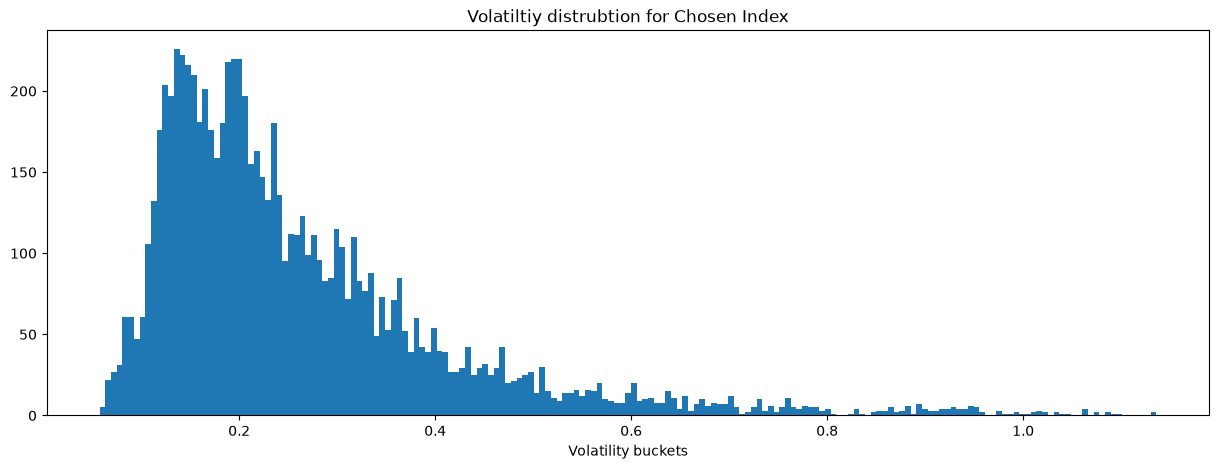

In [113]:
log_return_index_mean = log_return_index_daily.mean()
ri_minus_rmean_index = ((log_return_index_daily) - log_return_index_mean ) **2
sum_ri_minus_rmean_index = (((log_return_index_daily) - log_return_index_mean ) **2).rolling(window).sum()
var_index = (1/(len(log_return_index_daily) -1) * sum_ri_minus_rmean_index) * (252/window)
vol_index = np.sqrt(var_index) * 100
print(vol_index.mean())
plt.figure(figsize=(15,5))
plt.hist(vol_spx, bins=185)
plt.title("Volatiltiy distrubtion for Chosen Index") 
plt.xlabel("Volatility buckets")
plt.show()

The GARCH model assumes clustering, here showing the autocorrelation tending towardds zero as n goes to intifity proves this clustering. This allows us to model our voaltiltiy using GARCH. 

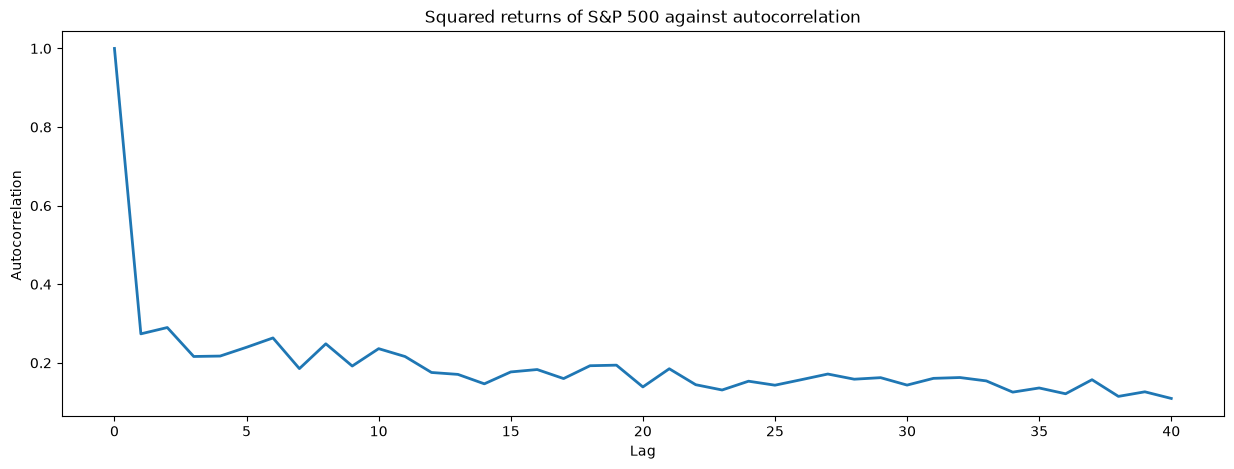

In [114]:
from statsmodels.graphics.tsaplots import acf
ln_rets_index = log_return_index_daily.dropna()
squared_index_returns = ln_rets_index ** 2
acf_index_values = acf(squared_index_returns, nlags=40)
plt.figure(figsize=(15,5))
plt.plot(acf_index_values, linewidth=2)
plt.title("Squared returns of S&P 500 against autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation ")
plt.show()

## Using GARCH

After showing our volatility is clustered. We can answer what is GARCH? GARCH is Generalised Autoregressive Conditional Herositkatisy. The formula for GARCH is below 

$$
\sigma_t^2 = \underbrace{\omega}_{\text{Long Run Term }} + \alpha\underbrace{\epsilon_{t-1}^2}_{\text{ARCH TERM}} + \beta\underbrace{\sigma_{t-1}^2}_{\text{GARCH TERM}}
$$ 

The first two terms are simply just the ARCH(1) developed by Engle, with $\alpha$ being the weighting on the recent shock(squared residual). The final term is what makes it our GARCH model. What we calculate below is 

$$
E[\sigma_{t+k}^2] = \omega + E[\epsilon_{t+k-1}^2] + E[\sigma_{t+k-1}^2]
$$
here is the most elegant part connecting the last two terms in the previous equation. Our $\epsilon_{t+k-1}^2$ is one specific realised deviation from a small near zero mean squared. So when taking a conditional expectation what is the information does $\epsilon_{t+k-1}^2$ possesses, we can say that 

$$ 
\epsilon_{t+k-1} = \sigma_{t+k-1} z_{t+k-1}
$$ 

Where the $z_{t+k-1}$ is independently, identically distributed so all of the $z_{t}$ are of the same distribution. This why $E[z_{t+k-1}]=1$. this means when we take the conditional expectation 

$$
E[\epsilon_{t+k-1}^2] = E[\sigma_{t+k-1}^2] E[z_{t+k-1}^2] = E[\sigma_{t+k-1}^2]
$$
Now this is useful as we can plug this into our GARCH Formula to see:
$$
E[\sigma_{t+k}^2] = \omega + (\alpha + \beta)E[\sigma_{t+k-1}^2]
$$
From Conditional expectation we see 
$$
E[\sigma_{t+k}^2] = \omega + (\alpha + \beta)E[\sigma_{t+k-1}^2] = \omega + (\alpha + \beta)(\omega + (\alpha + \beta)E[\sigma_{t+k-2}^2]
$$
We can see this is recursive so using our geometric series formula $ \sum{a_i}_{i=0}^{k} = \frac{1-a^k}{1-a}$ apply this to the coefficient of the $\omega$ term we gain:
$$
E[\sigma_{t+k}^2] = \omega \left(\frac{1-(\alpha +\beta)^k}{1-(\alpha + \beta)}\right) + (\alpha + \beta)^kE[\sigma_{t}^2]
$$
This shows to us a very important condition called our 'stationarity condition', as seen below. I first ran into this concept of stationarity when building a pairs trading project. Stationarity says that a process has 3 constant parts: constant mean, constant variance and constant autocovariance structure. This is very apt to the project as we assume that the VRP has a constant mean value over the whole time period, another very key assumption is that the size of the fluctuations is constant. However, this is exactly what GARCH models violations of. 
$$
\alpha + \beta < 1
$$
Now to address the walk-forward validation. So in the previous equations $\omega$, $\alpha$ and $\beta$ have all been constant. This is what our walk-forward validation addresses. Each fold the best parameter which best fits the data in that fold is chosen, so we have for each fold a recursion formula. One thing to highlight is how the validation process actually works
$$
\text{Training Period}_1 \subset \text{Training Period}_2 \subset ..... \subset \text{Training Period}_k
$$
So for each fold we have $ j= 0, ....., \text{horizon} $ 
$$
E[\sigma_{t_k + j}^2] = \omega \left(\frac{1-(\alpha +\beta)^j}{1-(\alpha + \beta)}\right) + (\alpha + \beta)^jE[\sigma_{t_k}^2]
$$

<Axes: title={'center': 'Forecasted Vs Realised Returns'}, xlabel='Time', ylabel='Volatility'>

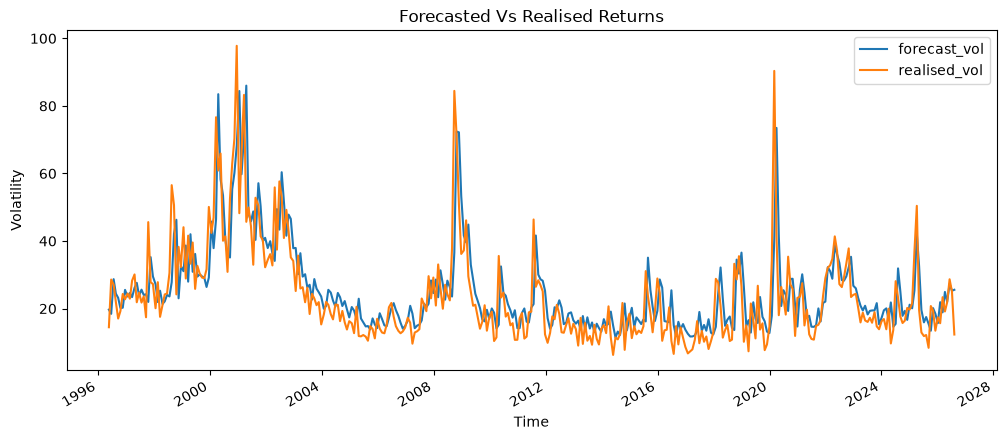

In [115]:
def walk_forward_validation(returns, min_train=350, horizon=21, p=1, q=1, dist='normal'):

    results = []
    n = len(returns)
    start= min_train
    while start + horizon <= n:
        train_data = returns.iloc[:start]
        model = arch_model(train_data, vol='Garch', p=p, q=q, dist=dist)
        fit = model.fit(disp='off')
        fc = fit.forecast(horizon=horizon, reindex=False)
        forecast_var = fc.variance.iloc[-1].sum() / 10000

        Forecast_date = returns.index[start - 1]
        realised_var = (returns.iloc[start : start + horizon] / 100 ) ** 2
        realised_var_sum = realised_var.sum()

        results.append({'forecast_start': Forecast_date, 'forecasted variance': forecast_var, 'realised variance': realised_var_sum,})
        start += horizon

    return pd.DataFrame(results).set_index('forecast_start')

wf_results = walk_forward_validation(returns_index, min_train=350, horizon=21)

wf_results['forecast_vol'] = np.sqrt(wf_results['forecasted variance'] * (252/21)) * 100
wf_results['realised_vol'] = np.sqrt(wf_results['realised variance'] * (252/21)) * 100
wf_results[['forecast_vol', 'realised_vol']].plot(figsize=(12, 5),  xlabel='Time', ylabel='Volatility', title='Forecasted Vs Realised Returns')

# Using the VIX as a proxy for the fair strike and Defining Our VRP
Now we implement the idea built upon in the previous ..... section. We define our VRP as being 

$$
VRP = E_t^Q[Var_t] - E_t^P[Var_t]
$$

0.0006167738971667899


<Axes: title={'center': '$K_{Var}$ Vs Realised Variance'}, xlabel='Time', ylabel='Variance'>

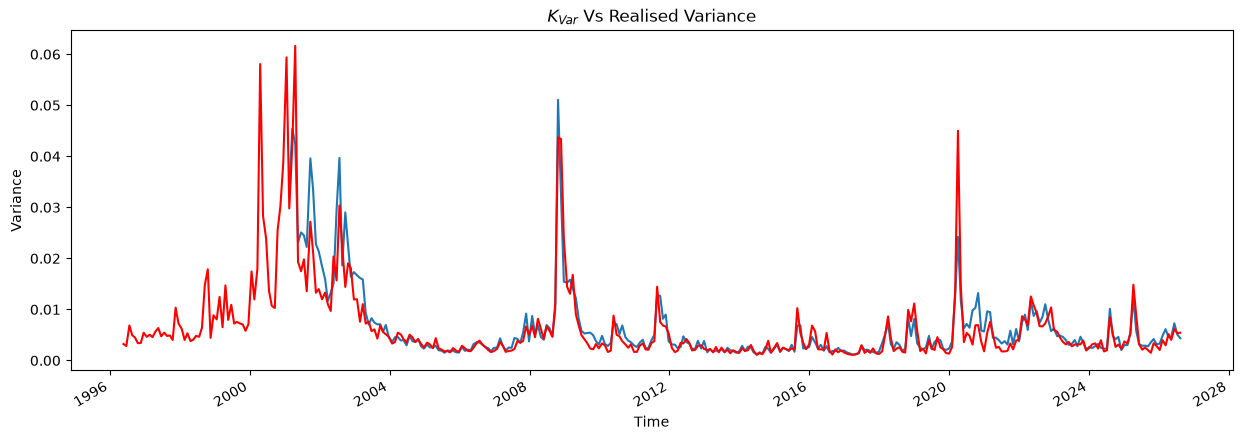

In [116]:
Kvar_index = ((prices_v_index / 100) ** 2 ) *( 30/365)
Kvar_aligned = Kvar_index.reindex(wf_results.index)
VRP_index = Kvar_aligned - (wf_results['forecasted variance'])
print(VRP_index.mean())
Kvar_aligned.plot(figsize=(15,5))
wf_results['forecasted variance'].plot(figsize=(15,5), color='Red',  xlabel='Time', ylabel='Variance', title='$K_{Var}$ Vs Realised Variance',)

This is an important step using a rolling mean, to avoid a look forward bias.
$$
Z_{VRP} = \frac{VRP - \hat{VRP}}{\sigma_{VRP}}
$$
This creates a Series that contains the Z scores for the 21 rolling day periods. 

In [117]:
# Define for a sample mean 
roll_VRP_mean = VRP_index.expanding(min_periods=12).mean().shift(1)
roll_VRP_std = VRP_index.expanding(min_periods=12).std().shift(1)
z_series = ((VRP_index - roll_VRP_mean) / roll_VRP_std).dropna()

## Signal Generation 
This is the same signal created in the orginal version. If the z-score of the VRP is greater than 'entry_req', then short volaittily as this tells us that the market is over expecting future volatitliy. This part is where we make the curical assumption that 

In [118]:
def signal(z_series, entry_req, window):
    position = 0
    positions = [] #  currenlty have an empty book
    Days_in_trade = 0
    
    for z in z_series:
        enter_today = 0 
        if position == 0:
            if z > entry_req:
                position = -1
                enter_today = -1
                Days_in_trade = 0
            elif z < - entry_req:
                position = 1
                enter_today = 1
                Days_in_trade = 0
        else:
            Days_in_trade += 1
            if Days_in_trade >= 1:
                    position = 0 
        positions.append(enter_today if position != 0 else 0)
    return pd.Series(positions, index= z_series.index)


## Optmisation of entry paramters 
This section optmisies the entry parameters of the z-score, it finds the best one. The for loop here is certainly making the code slower. 

In [119]:
def simple_train_test_backtest(z_series, entry_candidates, train_frac=0.4, hold_window=window):
    split_idx = int(len(z_series) * train_frac)
    train_z = z_series.iloc[:split_idx]
    test_z = z_series.iloc[split_idx:]
    best_req, best_score = None, -np.inf
    
    for req in entry_candidates:
        trial_positions = signal(train_z, req, hold_window)
        score = trial_positions.abs().sum()  # placeholder metric
        if score > best_score:
            best_req, best_score = req, score
    
    train_positions = signal(train_z, best_req, hold_window)
    test_positions = signal(test_z, best_req, hold_window)
    return train_positions, test_positions, best_req
    
train_positions, test_positions, chosen_req = simple_train_test_backtest(
    z_series.dropna(),
    entry_candidates=[i / 100000 for i in range(1, 200000)],
    train_frac=0.726,
    hold_window=window
)


# PnL and Metrics 
After choosing the best entry requirments we have to solve for changign from variance points to our notional amount to find the payoff for each contract th

In [120]:
def cumlative_pnl(positions, realized_variance_series):
    lagged_positions = positions.shift(1).fillna(0)
    pnl = -lagged_positions * realized_variance_series.diff()
    cumlative_pnl = pnl.cumsum()
    return cumlative_pnl
    
train_cumlative_pnl = cumlative_pnl(train_positions, daily_var_spx.loc[train_positions.index])
test_cumlative_pnl = cumlative_pnl(test_positions, daily_var_spx.loc[test_positions.index])    

In [121]:
def pnl(positions, realized_variance_series):
    lagged_positions = positions.shift(1).fillna(0)
    pnl = -lagged_positions * realized_variance_series.diff()
    return pnl
    
test_pnl = pnl(test_positions, daily_var_index.loc[test_positions.index])
train_pnl = pnl(train_positions, daily_var_index.loc[train_positions.index])   

### Cumlative Returns over time
Here we see the strategies cumlative returns over time, with the red line showing the split betwen the test and train sample data.

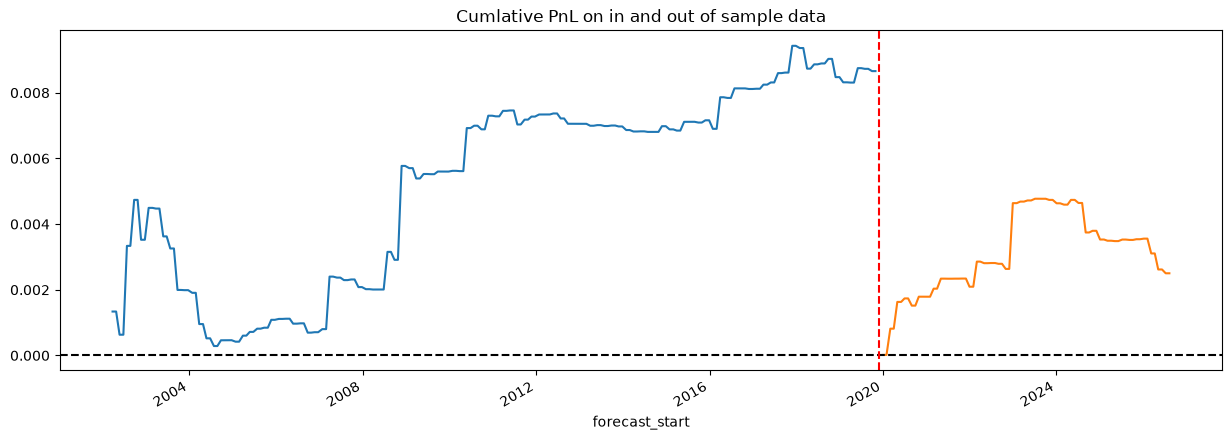

In [122]:
train_cumlative_pnl.plot()
test_cumlative_pnl.plot(figsize=(15,5), title='Cumlative PnL on in and out of sample data')
plt.axhline(0, linestyle='--', color='Black')
split = int(len(z_series) * 0.726)
plt.axvline(z_series.index[split], linestyle='--', color='Red')

### Cumlative Returns
These returns are a bit disappoting, in the next section I will analyse why the stratergy has returned this poorly. 

In [123]:
test_pnl = pnl(test_positions, daily_var_spx.loc[test_positions.index])
train_pnl = pnl(train_positions, daily_var_spx.loc[train_positions.index])
cumlative_return_test = (((1 + test_pnl).prod() -1 ) * 100).round(2).astype('str') + '%'
cumlative_return_train = (((1 + train_pnl).prod() -1 ) * 100).round(2).astype('str') + '%'
print(cumlative_return_test)
print(cumlative_return_train)

0.25%
0.87%


### Sharpe ratio

In [124]:
sharpe_ratio_test = (test_pnl.mean() / test_pnl.std()) * np.sqrt(252)
sharpe_ratio_train = (train_pnl.mean() / train_pnl.std()) * np.sqrt(252)

print(sharpe_ratio_test)
print(sharpe_ratio_train)

1.6023453815887692
1.5930888546590665


### Notional Returns
As we can see here the inflation adjusted returns would be horrible

<Axes: title={'center': 'Return of 1 million pounds'}, xlabel='Time', ylabel='Millions of Pounds'>

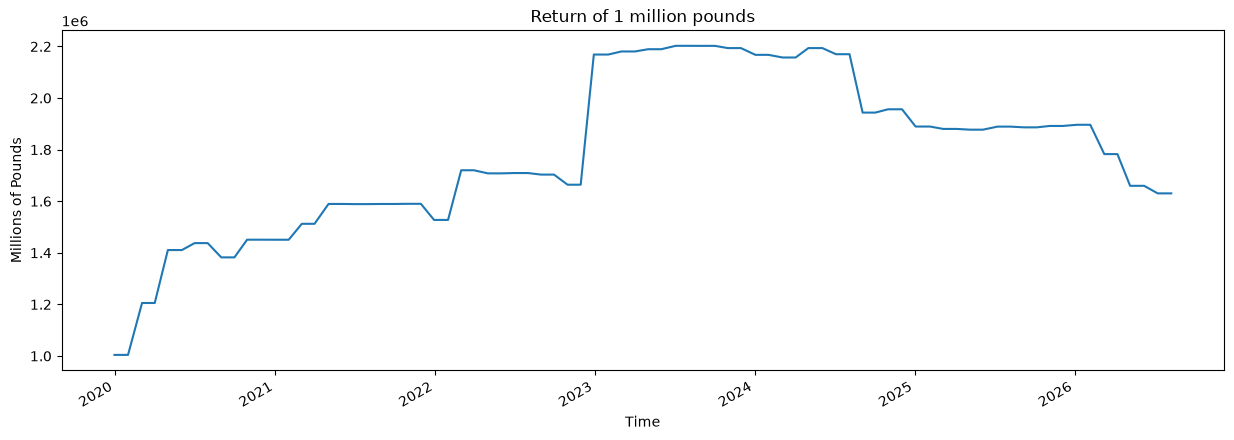

In [125]:
notional = 1_000_000  
pnl_annualized_variance_points = test_pnl * 252          
pnl_pounds = pnl_annualized_variance_points * notional 
total_pounds_ret = pnl_dollars.cumsum() + notional
total_pounds_ret.plot(figsize=(15,5), xlabel='Time' ,ylabel='Millions of Pounds', title='Return of 1 million pounds')

### Drawdowns

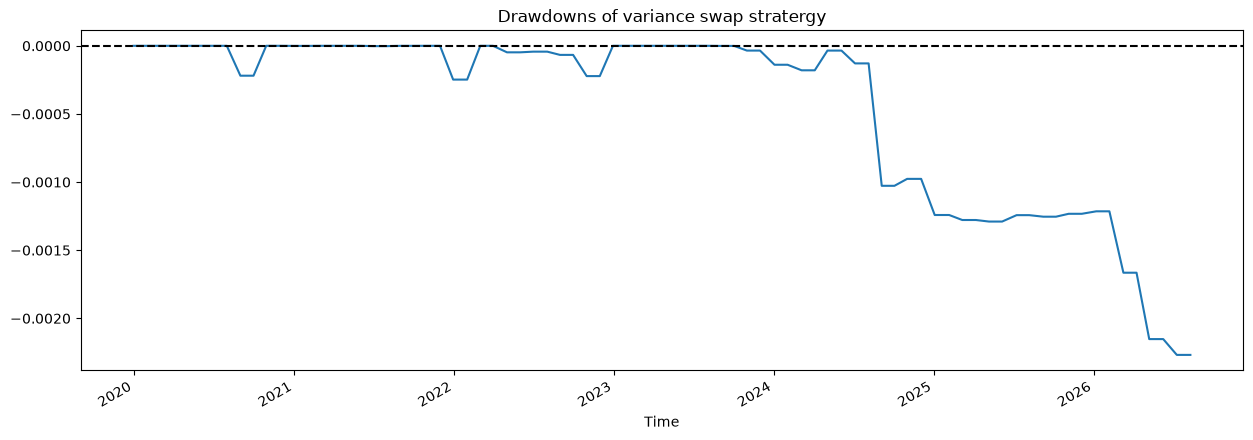

In [126]:
previous_peaks = wealth_index.cummax()
drawdowns = (wealth_index - previous_peaks) / previous_peaks
drawdowns.plot(figsize=(15,5),  xlabel='Time'  ,title='Drawdowns of variance swap stratergy')
plt.axhline(0, linestyle='--', color='Black')

# Conclusion
This is an apt place to end. In this section I have completed a walk forward validation of GARCH to avoid overfitting in our Volatility forecasting, and completed a simple train test back test on the z-score mean reversion aspect, finding an optimised parameter for entering a position. Then using this I create a cumulative and standard Pnl for the in and out of sample tests. This now leads us to ask questions about why the strategy has returned like this? Where is the PnL coming from? How does it compare to being run on other indices?

In [127]:
data_to_save = {
    'test_pnl': test_pnl,
    'train_pnl': train_pnl,
    'test_positions': test_positions,
    'train_positions': train_positions,
    'VRP_index': VRP_index,
    'z_series': z_series,
    'wf_results': wf_results,
    'Kvar_aligned': Kvar_aligned,
    'chosen_req': chosen_req,
}

with open('backtest_outputs.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)
print("Saved backtest outputs to backtest_outputs.pkl")

Saved backtest outputs to backtest_outputs.pkl


## List of Resources Used
P.Chan's Algorithmtic Trading

Hamiltion, Time Series Analysis

QuantConnect's walk-forward optimization docs#

Roman Pallocui's Youtube videos

PyQuant

Dainel Boctor's Youtube videos

MIT OCW Time Series Analysis

https://www.quantt.co.uk/resources/time-series-analysis-guide